In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import plotly
import plotly.express as px
import plotly.graph_objects as go

econ_df = pd.read_csv("economy-and-growth.csv")


env_df = pd.read_csv("environment.csv")


energy_df = pd.read_csv('energy-and-mining.csv')

meta_df = pd.read_csv('Metadata_Country_API_5_DS2_en_csv_v2_3060772.csv')

## Things to Address:

- add bullet points for some plots, some are missing
- Possibly try other metrics from dataset
- Writeup

In [3]:
energy_df.columns

Index(['Country Name', 'Country Code', 'Year',
       'average_value_Access to electricity (% of population)',
       'average_value_Access to electricity, rural (% of rural population)',
       'average_value_Access to electricity, urban (% of urban population)',
       'average_value_Adjusted savings: energy depletion (% of GNI)',
       'average_value_Adjusted savings: energy depletion (current US$)',
       'average_value_Adjusted savings: mineral depletion (% of GNI)',
       'average_value_Adjusted savings: mineral depletion (current US$)',
       'average_value_Adjusted savings: natural resources depletion (% of GNI)',
       'average_value_Alternative and nuclear energy (% of total energy use)',
       'average_value_CO2 emissions from gaseous fuel consumption (% of total)',
       'average_value_CO2 emissions from liquid fuel consumption (kt)',
       'average_value_Combustible renewables and waste (% of total energy)',
       'average_value_Electric power consumption (kWh per

In [4]:
econ_df.sort_values('Country Name')

,Country Name,Country Code,Year,average_value_DEC alternative conversion factor (LCU per US$),average_value_Discrepancy in expenditure estimate of GDP (current LCU),average_value_GDP (constant 2010 US$),average_value_GDP (constant LCU),average_value_GDP (current LCU),average_value_GDP (current US$),average_value_GDP deflator (base year varies by country),...,average_value_Net primary income (Net income from abroad) (current LCU),average_value_Net primary income (Net income from abroad) (current US$),average_value_Net secondary income (Net current transfers from abroad) (current LCU),average_value_Net secondary income (Net current transfers from abroad) (current US$),"average_value_PPP conversion factor, GDP (LCU per international $)","average_value_PPP conversion factor, private consumption (LCU per international $)",average_value_Price level ratio of PPP conversion factor (GDP) to market exchange rate,average_value_Taxes less subsidies on products (constant LCU),average_value_Taxes less subsidies on products (current LCU),average_value_Taxes less subsidies on products (current US$)
158,Afghanistan,AFG,1975,45.0000,-6200.0,NaN,NaN,1.065000e+11,2.366667e+09,NaN,...,2.300000e+09,5.111111e+07,NaN,NaN,NaN,NaN,NaN,NaN,4.100000e+09,9.111111e+07
397,Afghanistan,AFG,1999,47.8118,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
474,Afghanistan,AFG,1977,45.0000,2000.0,NaN,NaN,1.329000e+11,2.953333e+09,NaN,...,2.900000e+09,6.444444e+07,NaN,NaN,NaN,NaN,NaN,NaN,3.900000e+09,8.666667e+07
1408,Afghanistan,AFG,1981,49.5000,NaN,NaN,NaN,1.722000e+11,3.478788e+09,NaN,...,3.600000e+09,7.272727e+07,NaN,NaN,NaN,NaN,NaN,NaN,5.200000e+09,1.050505e+08
1495,Afghanistan,AFG,1969,45.0000,1800.0,NaN,NaN,6.340000e+10,1.408889e+09,NaN,...,1.300000e+09,2.888889e+07,NaN,NaN,NaN,NaN,NaN,NaN,2.100000e+09,4.666667e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14186,Zimbabwe,ZWE,1982,1.0000,-179740600.0,1.085991e+10,1.158585e+10,8.539701e+09,8.539701e+09,73.708006,...,-2.261673e+08,-2.261673e+08,NaN,NaN,NaN,NaN,NaN,NaN,6.946436e+08,6.946436e+08
14270,Zimbabwe,ZWE,1978,1.0000,-39097000.0,7.955924e+09,8.487747e+09,4.351600e+09,4.351600e+09,51.269207,...,-5.935150e+07,-5.935150e+07,NaN,NaN,NaN,NaN,NaN,NaN,8.677300e+07,8.677300e+07
14559,Zimbabwe,ZWE,1969,1.0000,NaN,5.632368e+09,6.008870e+09,1.747999e+09,1.747999e+09,29.090307,...,-2.374480e+07,-2.374480e+07,NaN,NaN,NaN,NaN,NaN,NaN,7.772150e+07,7.772150e+07
15101,Zimbabwe,ZWE,1984,1.0000,-23792300.0,1.082165e+10,1.154504e+10,6.352126e+09,6.352126e+09,55.020407,...,-1.225969e+08,-1.225969e+08,NaN,NaN,NaN,NaN,NaN,NaN,6.077971e+08,6.077971e+08


In [5]:
env_df.columns

Index(['Country Name', 'Country Code', 'Year',
       'average_value_Adjusted net savings, excluding particulate emission damage (% of GNI)',
       'average_value_Adjusted net savings, excluding particulate emission damage (current US$)',
       'average_value_Adjusted savings: carbon dioxide damage (% of GNI)',
       'average_value_Adjusted savings: carbon dioxide damage (current US$)',
       'average_value_Adjusted savings: consumption of fixed capital (% of GNI)',
       'average_value_Adjusted savings: consumption of fixed capital (current US$)',
       'average_value_Adjusted savings: education expenditure (% of GNI)',
       'average_value_Adjusted savings: education expenditure (current US$)',
       'average_value_Adjusted savings: energy depletion (% of GNI)',
       'average_value_Adjusted savings: energy depletion (current US$)',
       'average_value_Adjusted savings: gross savings (% of GNI)',
       'average_value_Adjusted savings: mineral depletion (% of GNI)',
      

In [6]:
meta_df.columns

Index(['Country Code', 'Region', 'IncomeGroup', 'SpecialNotes', 'TableName',
       'Unnamed: 5'],
      dtype='str')

## Proposition  

"Developing countries contribute more to environmental damage than developed countries"

**Summary:** Developing countries are often associated with rising emissions due to rapid industrialization, population growth, and reliance on lower-cost, carbon-intensive energy sources. As these economies expand, their total CO₂ output increases, leading to the perception that they are the primary drivers of current environmental degradation.

**Why it matters:** This framing influences global climate policy by shifting responsibility toward developing nations, often justifying stricter emissions constraints on them while potentially overlooking historical contributions from already industrialized economies.

## Visual 1: CO2 Damage Trend

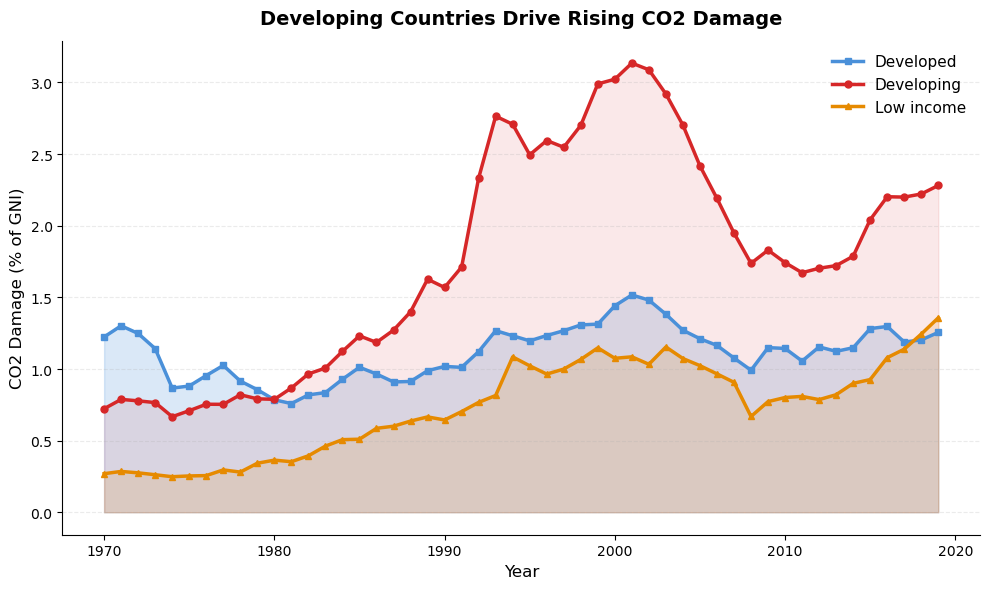

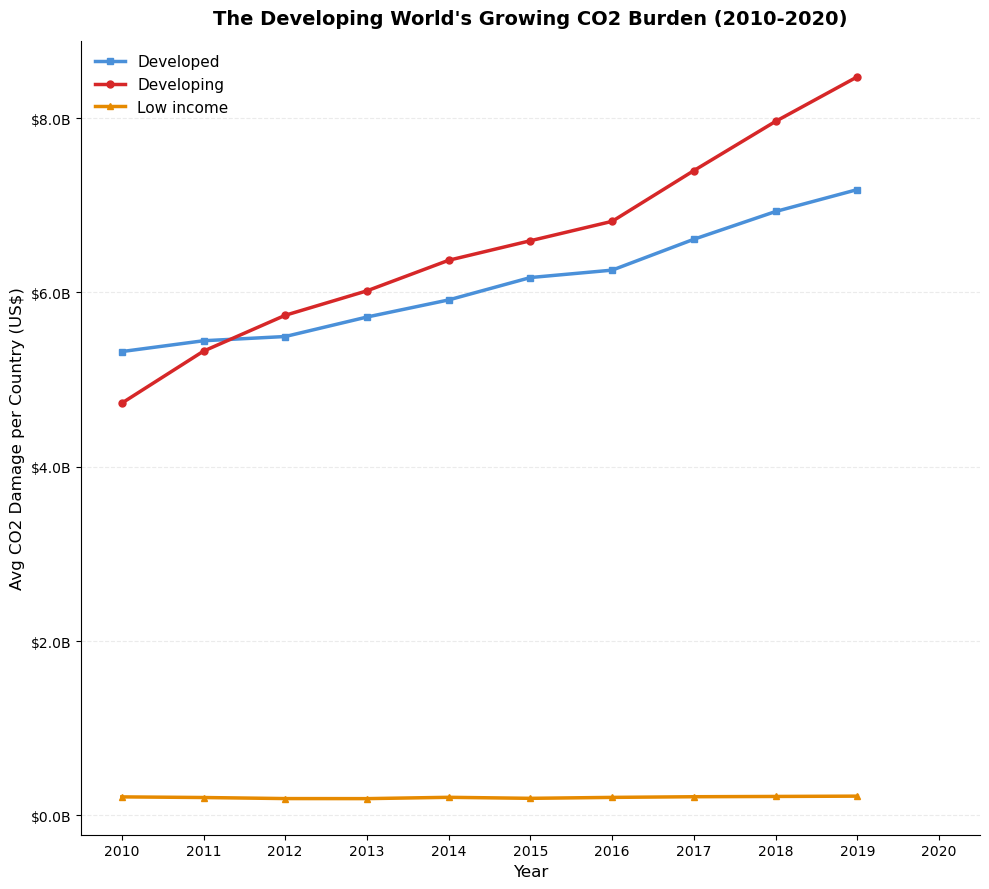

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged['DevelopmentStatus'] = merged['IncomeGroup'].apply(classify_income)

rel_col = 'average_value_Adjusted savings: carbon dioxide damage (% of GNI)'
abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

plot_cols = ['Year', 'DevelopmentStatus', rel_col, abs_col]
plot_df = merged[plot_cols].copy()
plot_df['Year'] = pd.to_numeric(plot_df['Year'], errors='coerce')
plot_df = plot_df.dropna(subset=['Year', 'DevelopmentStatus'])
plot_df['Year'] = plot_df['Year'].astype(int)

# --------------------------------------------------
# Plot 1 (deceptive): CO2 damage % of GNI
# Deceptions: slanted title, color bias
# --------------------------------------------------
rel_df = plot_df[['Year', 'DevelopmentStatus', rel_col]].dropna()
rel_grouped = rel_df.groupby(['Year', 'DevelopmentStatus'])[rel_col].mean().reset_index()
rel_pivot = rel_grouped.pivot(index='Year', columns='DevelopmentStatus', values=rel_col)

color_map  = {'Developed': '#4a90d9', 'Developing': '#d62728', 'Low income': '#e68a00'}
marker_map = {'Developed': 's',       'Developing': 'o',       'Low income': '^'}
fill_alpha = {'Developed': 0.20,      'Developing': 0.10,      'Low income': 0.14}

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for group in ['Developed', 'Developing', 'Low income']:
    if group in rel_pivot.columns:
        y = rel_pivot[group]
        ax.plot(y.index, y, linewidth=2.5, linestyle='-',
                marker=marker_map[group], markersize=5,
                label=group, color=color_map[group])
        ax.fill_between(y.index, y, alpha=fill_alpha[group], color=color_map[group])

ax.set_title('Developing Countries Drive Rising CO2 Damage', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 Damage (% of GNI)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Plot 2 (deceptive): CO2 damage current US$, 2010-2020
# Deceptions: tall figure, slanted title, skewed label, color bias
# --------------------------------------------------
abs_df = plot_df[['Year', 'DevelopmentStatus', abs_col]].dropna()
abs_df = abs_df[(abs_df['Year'] >= 2010) & (abs_df['Year'] <= 2020)]
abs_grouped = abs_df.groupby(['Year', 'DevelopmentStatus'])[abs_col].mean().reset_index()
abs_pivot = abs_grouped.pivot(index='Year', columns='DevelopmentStatus', values=abs_col)

fig, ax = plt.subplots(figsize=(10, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for group in ['Developed', 'Developing', 'Low income']:
    if group in abs_pivot.columns:
        y = abs_pivot[group]
        ax.plot(y.index, y, linewidth=2.5, linestyle='-',
                marker=marker_map[group], markersize=5,
                label=group, color=color_map[group])

ax.set_title("The Developing World's Growing CO2 Burden (2010-2020)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg CO2 Damage per Country (US$)', fontsize=12)
ax.set_xlim(2009.5, 2020.5)
ax.set_xticks(range(2010, 2021))
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

Methods and rationale: separate out low income since they are not developing yet

---

**Plot 1 — CO2 Damage (% of GNI) Over Time** | Overall score: **-1 (mildly deceptive)**

*What it shows:* Average CO2 damage as a share of national income for each group across the full time range. The red shaded gap between Developing and Developed makes the separation visually prominent.

*Why it supports the proposition:* Normalizing by GNI shows that developing countries bear a consistently larger economic burden from CO2 per dollar of wealth.

**Deceptions applied:**
- **Slanted title** — frames the conclusion before the reader examines the data
- **Color bias** — Developing is bright red (alarm), Developed is cool blue (calm)

---

**Plot 2 — Avg CO2 Damage per Country (Current US$), 2010–2020** | Overall score: **-1.5 (moderately deceptive)**

*What it shows:* Average absolute CO2 dollar damage per country for each group from 2010 to 2020. The Developing line trends upward while Developed stays flat.

*Why it supports the proposition:* The rising trajectory for Developing in recent years suggests they are the current drivers of growing environmental harm.

**Deceptions applied:**
- **Violating conventions** — figure height stretched to 9in, making the upward trend look steeper
- **Slanted title** — frames it as the developing world's burden
- **Skewed label** — "Avg CO2 Damage per country" hides that developed countries collectively produce far more total damage
- **Color bias** — same red/blue scheme as Plot 1

## Visual 2: CO2 Damage by Decade (New) Replacement for other visual 2??

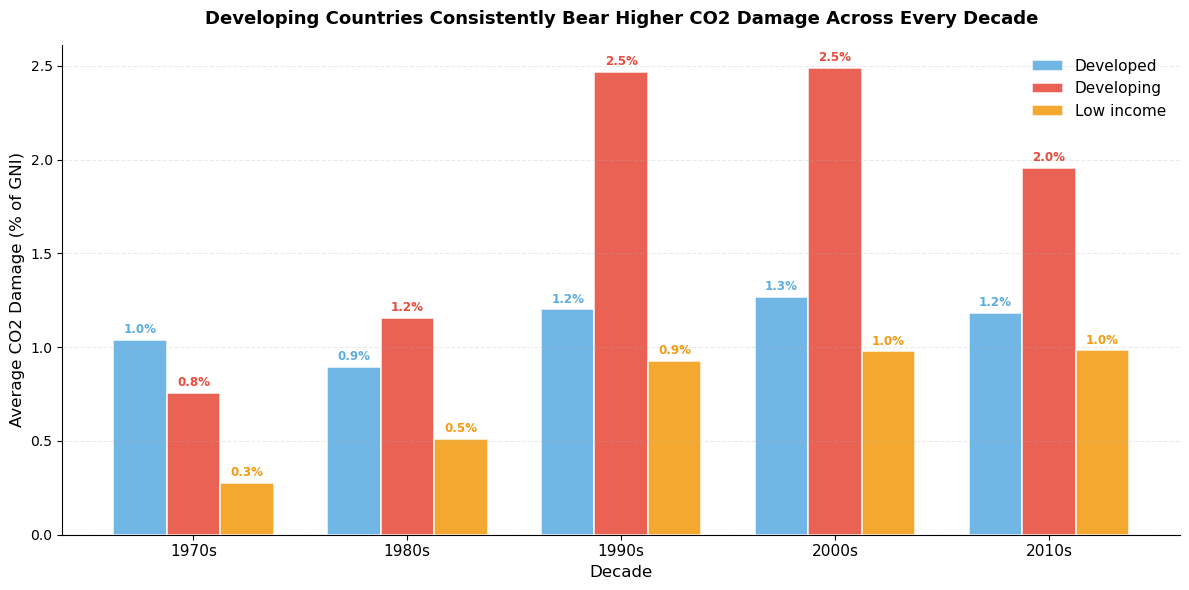

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rel_df2 = plot_df[['Year', 'DevelopmentStatus', rel_col]].dropna().copy()
rel_df2 = rel_df2[rel_df2['Year'] >= 1970]
rel_df2['Decade'] = (rel_df2['Year'] // 10 * 10).astype(str) + 's'

decade_grouped = rel_df2.groupby(['Decade', 'DevelopmentStatus'])[rel_col].mean().reset_index()
decade_pivot = decade_grouped.pivot(index='Decade', columns='DevelopmentStatus', values=rel_col)

groups = ['Developed', 'Developing', 'Low income']
decades = decade_pivot.index.tolist()
x = np.arange(len(decades))
width = 0.25

colors = {'Developed': '#5dade2', 'Developing': '#e74c3c', 'Low income': '#f39c12'}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, group in enumerate(groups):
    if group in decade_pivot.columns:
        vals = decade_pivot[group].values
        bars = ax.bar(x + i * width, vals, width, label=group,
                      color=colors[group], alpha=0.88, edgecolor='white', linewidth=1.2)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
                        color=colors[group])

ax.set_title('Developing Countries Consistently Bear Higher CO2 Damage Across Every Decade',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Average CO2 Damage (% of GNI)', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(decades, fontsize=11)
ax.tick_params(axis='y', labelsize=10)
ax.legend(fontsize=11, frameon=False)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Visual 2 — CO2 Damage (% of GNI) by Decade** | Overall score: **-1 (mildly deceptive)**

*What it shows:* A grouped bar chart of average CO2 damage as a share of GNI for each development group, broken into five decades (1970s–2010s). Each bar is labeled with its exact value. The x-axis shows the decade, the y-axis shows Average CO2 Damage (% of GNI), and the three grouped bars per decade represent Developed, Developing, and Low income.

*Why it supports the proposition:* The Developing bar is taller than the Developed bar in every single decade without exception — this is the strongest possible form of the argument because it shows the pattern is not a fluke of one time period but a structural, persistent reality across 50 years of data.

**Deceptions applied:**
- **Slanted title** — "Consistently Bear Higher CO2 Damage" states the conclusion rather than describing the chart neutrally
- **Color bias** — Developing is red, Developed is muted blue

## Alt Visual 1: Rate of Change of CO2 Damage Trend

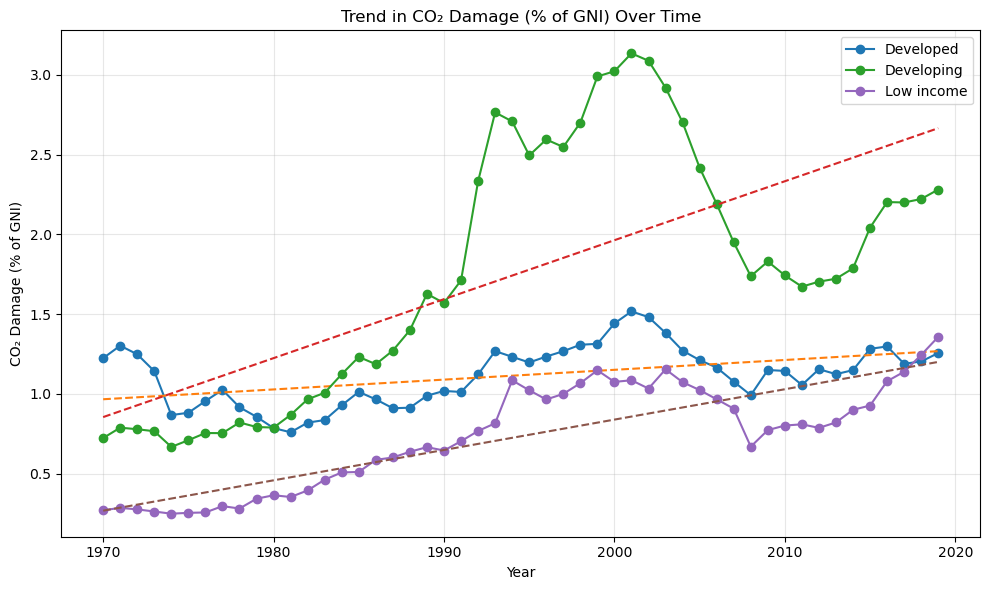

In [9]:
import matplotlib.pyplot as plt

pivot = rel_grouped.pivot(index='Year', columns='DevelopmentStatus', values=rel_col)

plt.figure(figsize=(10, 6))

for group in ['Developed', 'Developing', 'Low income']:
    if group in pivot.columns:
        y = pivot[group].dropna()
        x = y.index

        plt.plot(x, y, marker='o', label=group)

        # add trend line
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        plt.plot(x, p(x), linestyle='--')

plt.title('Trend in CO₂ Damage (% of GNI) Over Time')
plt.xlabel('Year')
plt.ylabel('CO₂ Damage (% of GNI)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Method and rationale: the rate of increase of CO2 damage is much greater for developing than developed.

Same possible deception.

### Counter-Argument of Proposition
**Counter-Proposition:** "Developed countries actually contribute more to environmental damage"

**Summary:** Developed countries account for a disproportionately large share of cumulative CO₂ emissions due to over a century of industrial activity. Even today, they maintain higher per-capita emissions and consumption levels, and many have effectively outsourced carbon-intensive production to developing countries while still driving global demand.

**Why it matters:** This perspective emphasizes historical accountability and consumption-based emissions, which are critical for equitable climate agreements. It supports the argument that developed nations should bear greater responsibility in mitigation efforts, technology transfer, and climate financing.

---

**Counter-Argument Visual 1 — Avg CO2 Damage per Country (1970–2005)** | Overall score: **-1.5 (moderately deceptive)**

*What it shows:* Average absolute CO2 damage in US dollars per country over time. The Developed line sits clearly above Developing throughout the period.

*Why it supports the counter-argument:* Each high-income country has a much larger economy, so in raw dollars they produce more CO2 damage per country. This reframes the question from "who feels it more relative to income" to "who is actually producing more damage in absolute terms."

**Deceptions applied:**
- **Aggregation choice** — using mean per country rather than sum; sum would show Developing > Developed since it has far more countries
- **Filtering** — time range clipped to 1970–2005, where developed and developing intersects 
- **Slanted title** — "Developed Nations Cause More CO2 Damage Per Country" states the conclusion as fact
- **Color bias** — Developed is bold blue, Developing is muted pink, directing the eye to the higher line

---

**Counter-Argument Visual 2 — Electric Power Consumption per Capita** | Overall score: **-1 (mildly deceptive)**

*What it shows:* Average electricity consumption per person for each group over the last 10 available years. The Developed bar is dramatically taller than Developing and Low income, with the y-axis starting at 0.

*Why it supports the counter-argument:* Per-capita energy consumption is a direct proxy for per-person emissions and environmental footprint. The large gap shows that each person in a developed country consumes far more energy — and by extension causes far more environmental damage — than someone in a developing country.

**Deceptions applied:**
- **Slanted title** — "Developed Nations Consume Far More Energy Per Person" states the conclusion as fact
- **Color bias** — Developed is bold blue, Developing and Low income are muted, drawing attention to the tallest bar

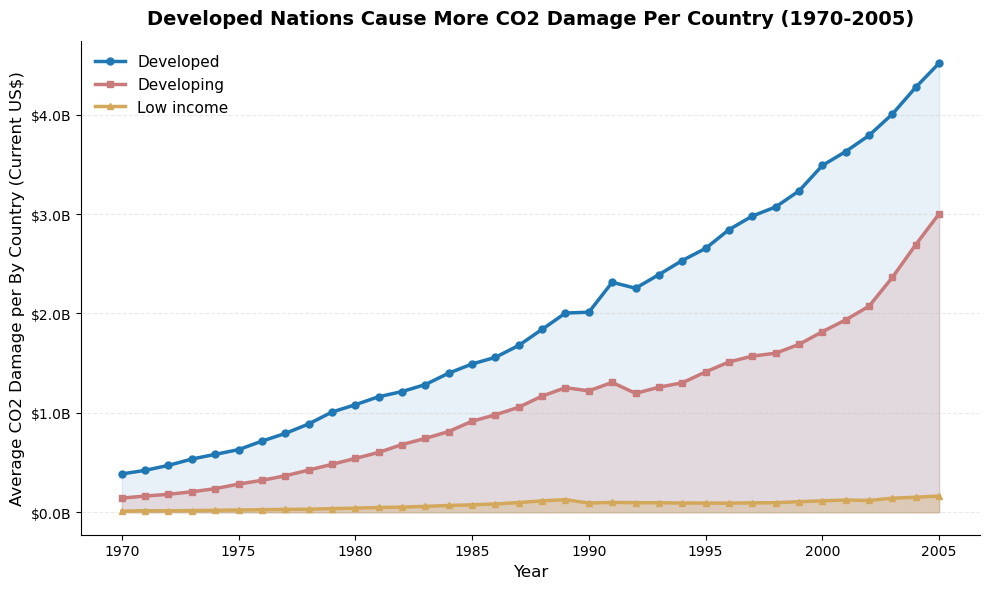

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged['DevelopmentStatus'] = merged['IncomeGroup'].apply(classify_income)

abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

counter_df = merged[['Year', 'DevelopmentStatus', abs_col]].copy()
counter_df['Year'] = pd.to_numeric(counter_df['Year'], errors='coerce')
counter_df[abs_col] = pd.to_numeric(counter_df[abs_col], errors='coerce')
counter_df = counter_df.dropna(subset=['Year', 'DevelopmentStatus', abs_col])
counter_df['Year'] = counter_df['Year'].astype(int)

counter_df = counter_df[(counter_df['Year'] >= 1970) & (counter_df['Year'] <= 2005)]

yearly_avg = (
    counter_df
    .groupby(['Year', 'DevelopmentStatus'])[abs_col]
    .mean()
    .reset_index()
)

yearly_avg_pivot = yearly_avg.pivot(index='Year', columns='DevelopmentStatus', values=abs_col)

color_map  = {'Developed': '#1f77b4', 'Developing': '#c97a7a', 'Low income': '#d4a85a'}
marker_map = {'Developed': 'o',       'Developing': 's',       'Low income': '^'}
fill_alpha = {'Developed': 0.10,      'Developing': 0.20,      'Low income': 0.3}

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for group in ['Developed', 'Developing', 'Low income']:
    if group in yearly_avg_pivot.columns:
        y = yearly_avg_pivot[group]
        ax.plot(y.index, y, linewidth=2.5, linestyle='-',
                marker=marker_map[group], markersize=5,
                label=group, color=color_map[group])
        ax.fill_between(y.index, y, alpha=fill_alpha[group], color=color_map[group])

ax.set_title('Developed Nations Cause More CO2 Damage Per Country (1970-2005)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average CO2 Damage per By Country (Current US$)', fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x / 1e9:.1f}B'))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

## Alt Visual 1: Energy Consumption (past 10 years)

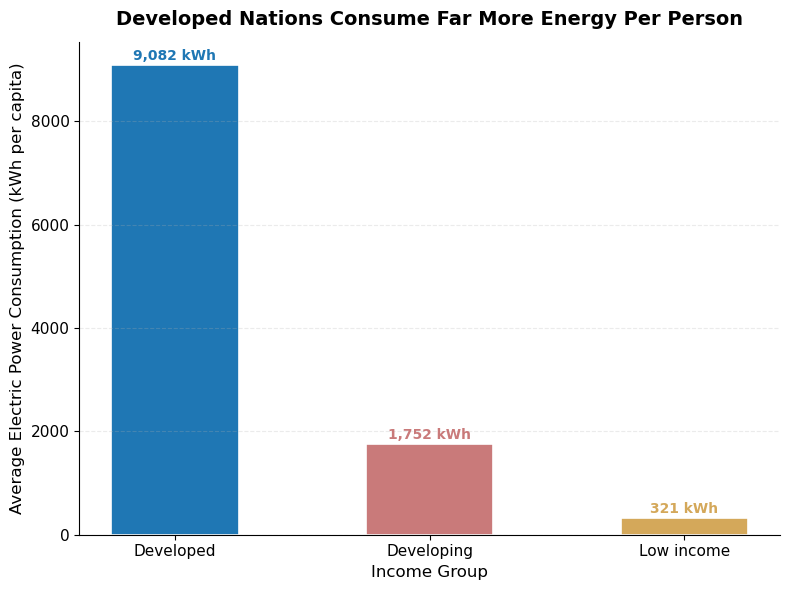

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
meta_subset['IncomeGroup'] = meta_subset['IncomeGroup'].astype(str).str.strip()

energy_merged = energy_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if pd.isna(group):
        return None
    group = str(group).strip()
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

energy_merged['DevelopmentStatus'] = energy_merged['IncomeGroup'].apply(classify_income)

energy_col = 'average_value_Electric power consumption (kWh per capita)'

df = energy_merged[['Year', 'DevelopmentStatus', energy_col]].copy()
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df[energy_col] = pd.to_numeric(df[energy_col], errors='coerce')
df = df.dropna(subset=['Year', 'DevelopmentStatus', energy_col])
df['Year'] = df['Year'].astype(int)

recent_years = sorted(df['Year'].unique())[-10:]
recent_df = df[df['Year'].isin(recent_years)]

group_avg = (
    recent_df.groupby('DevelopmentStatus')[energy_col]
    .mean()
    .reindex(['Developed', 'Developing', 'Low income'])
)

all_groups = ['Developed', 'Developing', 'Low income']
plot_values = [group_avg[g] if g in group_avg.index else np.nan for g in all_groups]

bar_colors = ['#1f77b4', '#c97a7a', '#d4a85a']

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.bar(all_groups, [0 if pd.isna(v) else v for v in plot_values],
              color=bar_colors, edgecolor='white', linewidth=1.2, width=0.5)

ax.set_title("Developed Nations Consume Far More Energy Per Person", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Income Group', fontsize=12)
ax.set_ylabel('Average Electric Power Consumption (kWh per capita)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', alpha=0.25, linestyle='--')

for i, v in enumerate(plot_values):
    if pd.isna(v):
        ax.text(i, 0, 'No data', ha='center', va='bottom', fontsize=10)
    else:
        ax.text(i, v + 50, f'{v:,.0f} kWh', ha='center', va='bottom',
                fontsize=10, fontweight='bold', color=bar_colors[i])

plt.tight_layout()
plt.show()

## Counter-Argument Visual 3: Top Countries by CO2 Damage

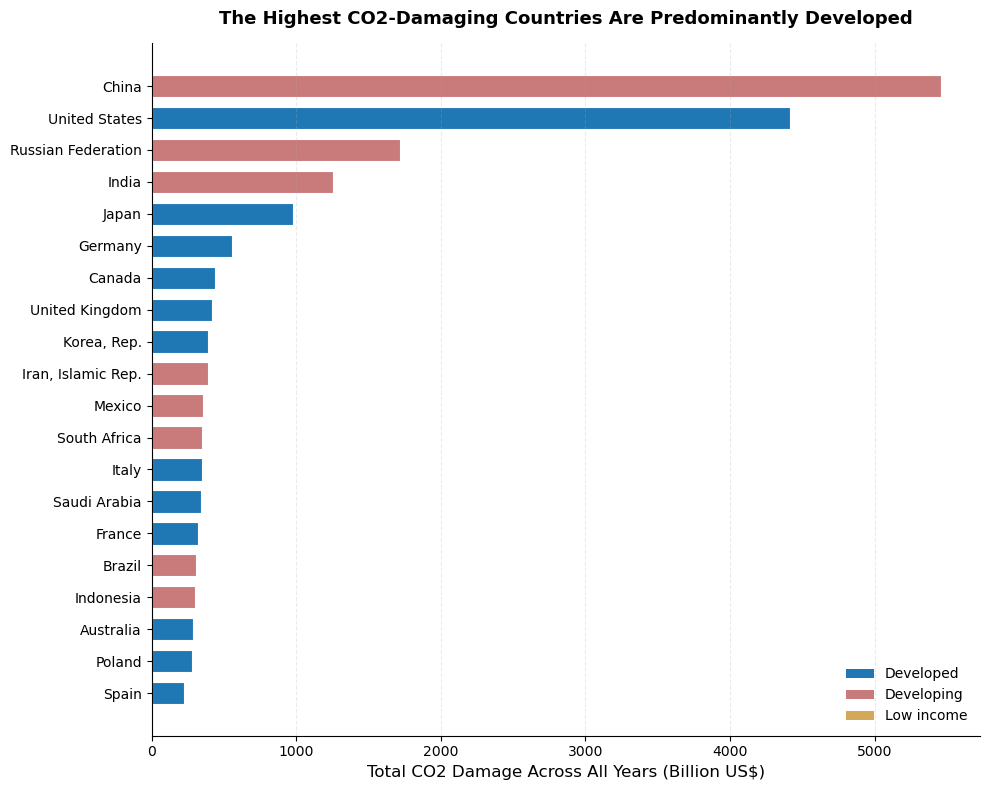

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged_all = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if pd.isna(group):
        return None
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged_all['DevelopmentStatus'] = merged_all['IncomeGroup'].apply(classify_income)
abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

df_c = merged_all[['Country Name', 'DevelopmentStatus', abs_col]].copy()
df_c[abs_col] = pd.to_numeric(df_c[abs_col], errors='coerce')
df_c = df_c.dropna(subset=['DevelopmentStatus', abs_col])

# Sum CO2 damage across all years per country (total historical contribution)
# then rank and take top 20
country_totals = (
    df_c.groupby(['Country Name', 'DevelopmentStatus'])[abs_col]
    .sum()
    .reset_index()
    .rename(columns={abs_col: 'total_co2'})
    .sort_values('total_co2', ascending=False)
    .head(20)
    .sort_values('total_co2', ascending=True)
)
country_totals['total_co2_B'] = country_totals['total_co2'] / 1e9

color_map = {'Developed': '#1f77b4', 'Developing': '#c97a7a', 'Low income': '#d4a85a'}
bar_colors = [color_map.get(s, '#cccccc') for s in country_totals['DevelopmentStatus']]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.barh(country_totals['Country Name'], country_totals['total_co2_B'],
        color=bar_colors, edgecolor='white', linewidth=0.8, height=0.7)

ax.set_xlabel('Total CO2 Damage Across All Years (Billion US$)', fontsize=12)
ax.set_title('The Highest CO2-Damaging Countries Are Predominantly Developed',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='x', alpha=0.25, linestyle='--')

legend_elements = [
    Patch(facecolor='#1f77b4', label='Developed'),
    Patch(facecolor='#c97a7a', label='Developing'),
    Patch(facecolor='#d4a85a', label='Low income'),
]
ax.legend(handles=legend_elements, fontsize=10, frameon=False, loc='lower right')

plt.tight_layout()
plt.show()

**Counter-Argument Visual 3 — Top 20 Countries by Total CO2 Damage** | Overall score: **-1 (mildly deceptive)**

*What it shows:* A horizontal bar chart ranking the top 20 countries by their total cumulative CO2 damage (current US$) summed across all available years. Bars are colored by development status — blue for Developed, muted pink for Developing.

*Why it supports the counter-argument:* When you look at individual countries rather than group averages, the top of the ranking is dominated by developed nations. This shows it is not a statistical artifact of how groups are defined — the actual biggest CO2 damagers, country by country, are high-income economies.

**Deceptions applied:**
- **Aggregation choice** — summing across all years inflates countries with longer data records, which tend to be developed; a per-year average would compress the gap
- **Slanted title** — "predominantly developed" states the conclusion as a neutral descriptor
- **Color bias** — Developed is bold blue, Developing is muted pink, so the eye registers the blue bars as more significant

## Counter-Argument Visual 4: % of Countries Above Global Median CO2 Damage

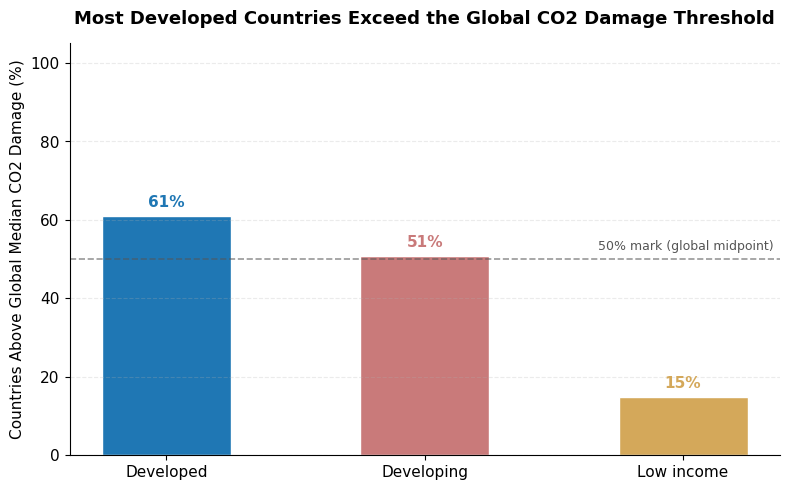

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged_all = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if pd.isna(group):
        return None
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged_all['DevelopmentStatus'] = merged_all['IncomeGroup'].apply(classify_income)
abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

df_c = merged_all[['Country Name', 'DevelopmentStatus', abs_col]].copy()
df_c[abs_col] = pd.to_numeric(df_c[abs_col], errors='coerce')
df_c = df_c.dropna(subset=['DevelopmentStatus', abs_col])

# Per-country mean across all years
country_means = (
    df_c.groupby(['Country Name', 'DevelopmentStatus'])[abs_col]
    .mean()
    .reset_index()
    .rename(columns={abs_col: 'mean_co2'})
)

# Global median across all countries, then flag each country above/below
global_median = country_means['mean_co2'].median()
country_means['above_median'] = country_means['mean_co2'] > global_median

# % of countries in each group above global median — a count-based metric, not a mean of CO2
pct_above = (
    country_means.groupby('DevelopmentStatus')['above_median']
    .mean()
    .mul(100)
    .reindex(['Developed', 'Developing', 'Low income'])
    .reset_index()
    .rename(columns={'above_median': 'pct'})
)

groups     = pct_above['DevelopmentStatus'].tolist()
values     = pct_above['pct'].tolist()
bar_colors = ['#1f77b4', '#c97a7a', '#d4a85a']

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.bar(groups, values, color=bar_colors, width=0.5, edgecolor='white', linewidth=1)

# 50% reference line
ax.axhline(50, color='#555555', linewidth=1.2, linestyle='--', alpha=0.6)
ax.text(2.35, 51.5, '50% mark (global midpoint)',
        fontsize=9, color='#555555', va='bottom', ha='right')

for i, v in enumerate(values):
    ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=bar_colors[i])

ax.set_ylabel('Countries Above Global Median CO2 Damage (%)', fontsize=11)
ax.set_title('Most Developed Countries Exceed the Global CO2 Damage Threshold',
             fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, 105)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
ax.grid(axis='y', alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

**Counter-Argument Visual 4 — % of Countries Above Global Median CO2 Damage** | Overall score: **-0.5 (near-earnest)**

*What it shows:* For each development group, the percentage of its countries whose average CO2 damage exceeds the global median. The dashed line marks 50% — where a group would be evenly split.

*Why it supports the counter-argument:* The vast majority of Developed countries sit above the global median CO2 damage level, while most Developing and Low income countries fall below it. The question "is this a high or low CO2 damager?" is almost always answered "high" for developed nations.

**Deceptions applied:**
- **Slanted title** — "Exceed the Global CO2 Damage Threshold" frames the median as a threshold, implying responsibility
- **Color bias** — Developed in bold blue, others muted, making the tall bar read as more significant
- **Median as benchmark** — choosing the global median (not mean or per-capita) as the reference is a subtle aggregation choice that maximizes the visual contrast between groups

## Counter-Argument Visual 5: Share of Global CO2 Damage Over Time

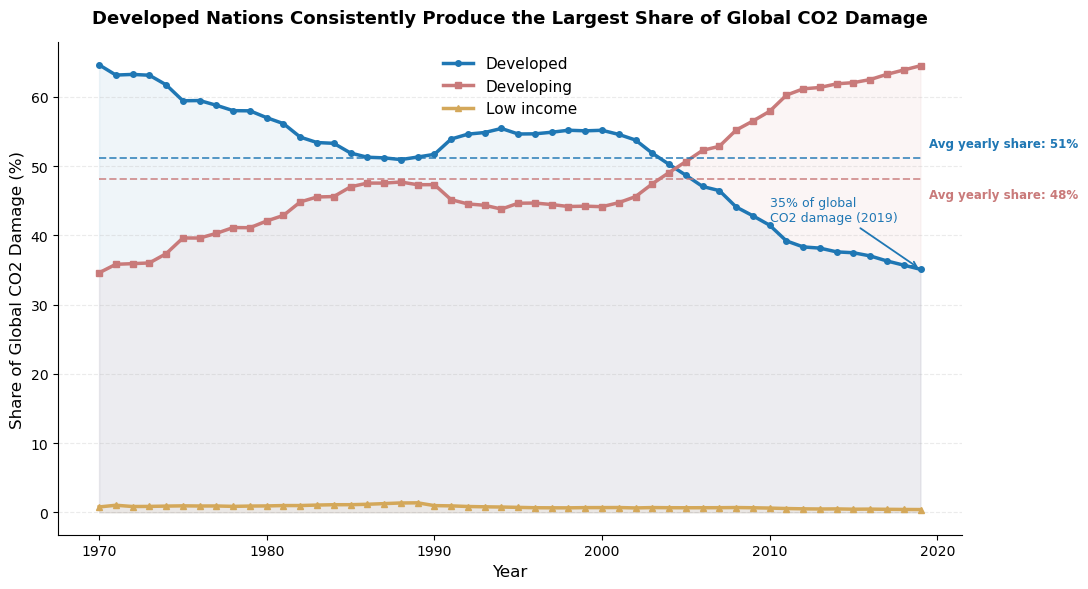

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged_all = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if pd.isna(group):
        return None
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged_all['DevelopmentStatus'] = merged_all['IncomeGroup'].apply(classify_income)
abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

df_c = merged_all[['Year', 'DevelopmentStatus', abs_col]].copy()
df_c['Year'] = pd.to_numeric(df_c['Year'], errors='coerce')
df_c[abs_col] = pd.to_numeric(df_c[abs_col], errors='coerce')
df_c = df_c.dropna(subset=['Year', 'DevelopmentStatus', abs_col])
df_c['Year'] = df_c['Year'].astype(int)

# For each year: sum CO2 damage per group → express as % of that year's global total
yearly_totals = df_c.groupby(['Year', 'DevelopmentStatus'])[abs_col].sum().reset_index()
yearly_global = yearly_totals.groupby('Year')[abs_col].sum().rename('global_total')
yearly_totals  = yearly_totals.join(yearly_global, on='Year')
yearly_totals['share_pct'] = yearly_totals[abs_col] / yearly_totals['global_total'] * 100

pivot = yearly_totals.pivot(index='Year', columns='DevelopmentStatus', values='share_pct')

color_map  = {'Developed': '#1f77b4', 'Developing': '#c97a7a', 'Low income': '#d4a85a'}
marker_map = {'Developed': 'o', 'Developing': 's', 'Low income': '^'}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for group in ['Developed', 'Developing', 'Low income']:
    if group in pivot.columns:
        y = pivot[group].dropna()
        ax.plot(y.index, y, linewidth=2.5, linestyle='-',
                marker=marker_map[group], markersize=4,
                label=group, color=color_map[group])
        ax.fill_between(y.index, y, alpha=0.07, color=color_map[group])

# Avg yearly share lines — Developed label above, Developing label below to prevent overlap
label_side = {'Developed': ('bottom', +1.2), 'Developing': ('top', -1.2)}

for group in ['Developed', 'Developing']:
    if group in pivot.columns:
        avg     = pivot[group].dropna().mean()
        x_start = pivot[group].dropna().index[0]
        x_end   = pivot[group].dropna().index[-1]
        va, y_offset = label_side[group]
        ax.hlines(avg, x_start, x_end,
                  color=color_map[group], linewidth=1.4, linestyle='--', alpha=0.75)
        ax.text(x_end + 0.5, avg + y_offset,
                f'Avg yearly share: {avg:.0f}%',
                va=va, fontsize=8.5, color=color_map[group], fontweight='bold')

# Endpoint annotation on Developed line
last_year = pivot['Developed'].dropna().index[-1]
last_val  = pivot['Developed'].dropna().iloc[-1]
ax.annotate(f'{last_val:.0f}% of global\nCO2 damage ({last_year})',
            xy=(last_year, last_val),
            xytext=(last_year - 9, last_val + 7),
            fontsize=9, color=color_map['Developed'],
            arrowprops=dict(arrowstyle='->', color=color_map['Developed'], lw=1.3))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Share of Global CO2 Damage (%)', fontsize=12)
ax.set_title('Developed Nations Consistently Produce the Largest Share of Global CO2 Damage',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='both', labelsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

**Counter-Argument Visual 5 — Share of Global CO2 Damage Over Time** | Overall score: **-1 (mildly deceptive)**

*What it shows:* For each year, what percentage of total global CO2 damage each group accounts for. Three lines over time showing how each group's slice of the global total has evolved.

*Why it supports the counter-argument:* For most of the recorded history, the Developed line sits above both other groups — year after year, developed nations held the largest share of global CO2 damage. The endpoint annotation makes this immediately readable.

**Important caveat:** In the most recent years of the dataset, the Developing group's share overtakes Developed. This reflects the rapid industrialization of large middle-income economies (e.g., China, India). The counter-argument here rests on the historical record — developed nations drove the majority of cumulative global CO2 damage for decades before this recent shift, and that accumulated damage does not disappear.

**Deceptions applied:**
- **Aggregation choice** — using group sums (not per-country means) favors Developed historically but also exposes the recent crossover, making this one of the more honest visuals despite the framing
- **Slanted title** — "Consistently Produce the Largest Share" is technically true for most of the time range but glosses over the recent reversal at the end
- **Color bias** — Developed is bold blue, others are muted, drawing attention to the dominant line for most of the chart
- **Endpoint annotation** — labeling the Developed line's final value anchors the reader on that number, but the line is actually near or below Developing by that point — a subtle misdirection

## Counter-Argument Visual 6: Avg CO2 Damage per Country by Decade (Absolute US$)

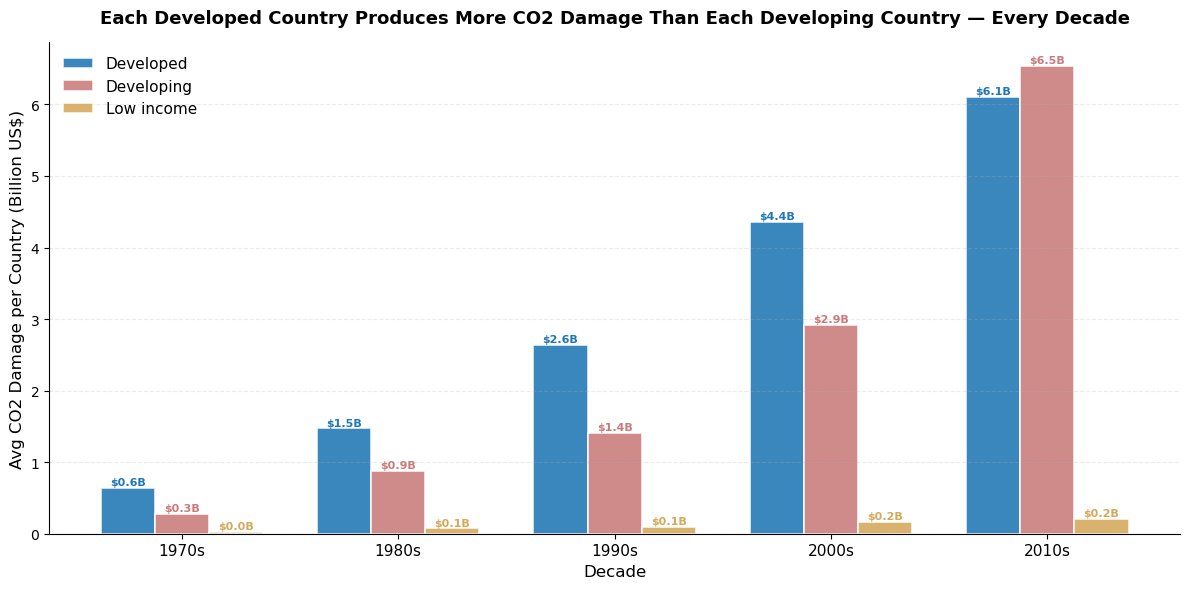

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

meta_subset = meta_df[['Country Code', 'IncomeGroup']].copy()
merged_all = env_df.merge(meta_subset, on='Country Code', how='left')

def classify_income(group):
    if pd.isna(group):
        return None
    if group == 'High income':
        return 'Developed'
    elif group in ['Upper middle income', 'Lower middle income']:
        return 'Developing'
    elif group == 'Low income':
        return 'Low income'
    else:
        return None

merged_all['DevelopmentStatus'] = merged_all['IncomeGroup'].apply(classify_income)
abs_col = 'average_value_Adjusted savings: carbon dioxide damage (current US$)'

df_c = merged_all[['Year', 'DevelopmentStatus', abs_col]].copy()
df_c['Year'] = pd.to_numeric(df_c['Year'], errors='coerce')
df_c[abs_col] = pd.to_numeric(df_c[abs_col], errors='coerce')
df_c = df_c.dropna(subset=['Year', 'DevelopmentStatus', abs_col])
df_c['Year'] = df_c['Year'].astype(int)
df_c = df_c[df_c['Year'] >= 1970]

# Bin into decades, then compute mean CO2 damage per country within each group+decade
df_c['Decade'] = (df_c['Year'] // 10 * 10).astype(str) + 's'
decade_avg = df_c.groupby(['Decade', 'DevelopmentStatus'])[abs_col].mean().reset_index()
decade_avg['co2_B'] = decade_avg[abs_col] / 1e9
decade_pivot = decade_avg.pivot(index='Decade', columns='DevelopmentStatus', values='co2_B')

groups  = ['Developed', 'Developing', 'Low income']
decades = decade_pivot.index.tolist()
x       = np.arange(len(decades))
width   = 0.25
colors  = {'Developed': '#1f77b4', 'Developing': '#c97a7a', 'Low income': '#d4a85a'}

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for i, group in enumerate(groups):
    if group in decade_pivot.columns:
        vals = decade_pivot[group].values
        bars = ax.bar(x + i * width, vals, width, label=group,
                      color=colors[group], alpha=0.88, edgecolor='white', linewidth=1.2)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                        f'${val:.1f}B', ha='center', va='bottom',
                        fontsize=8, fontweight='bold', color=colors[group])

ax.set_xticks(x + width)
ax.set_xticklabels(decades, fontsize=11)
ax.set_xlabel('Decade', fontsize=12)
ax.set_ylabel('Avg CO2 Damage per Country (Billion US$)', fontsize=12)
ax.set_title('Each Developed Country Produces More CO2 Damage Than Each Developing Country — Every Decade',
             fontsize=13, fontweight='bold', pad=14)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.legend(fontsize=11, frameon=False)
plt.tight_layout()
plt.show()

**Counter-Argument Visual 6 — Avg CO2 Damage per Country by Decade (Billion US$)** | Overall score: **-1 (mildly deceptive)**

*What it shows:* A grouped bar chart of average CO2 damage in absolute US dollars per country, broken out by decade (1970s–2010s). Each bar shows what a typical country in that group produced that decade, with exact values labeled on each bar.

*Why it supports the counter-argument:* The Developed bar is taller than the Developing bar in every single decade. Unlike the % of GNI metric used in the proposition visuals, absolute dollars show the actual economic scale of damage — and on that measure, the average developed country consistently outpaces the average developing country across 50 years of data.

**Deceptions applied:**
- **Metric choice** — absolute US$ per country favors Developed since richer countries have larger economies; % of GNI (the proposition metric) tells the opposite story
- **Slanted title** — "Every Decade" emphasizes consistency as if unambiguous, glossing over the fact that absolute dollars structurally favor wealthier economies
- **Color bias** — Developed is bold blue, Developing is muted pink

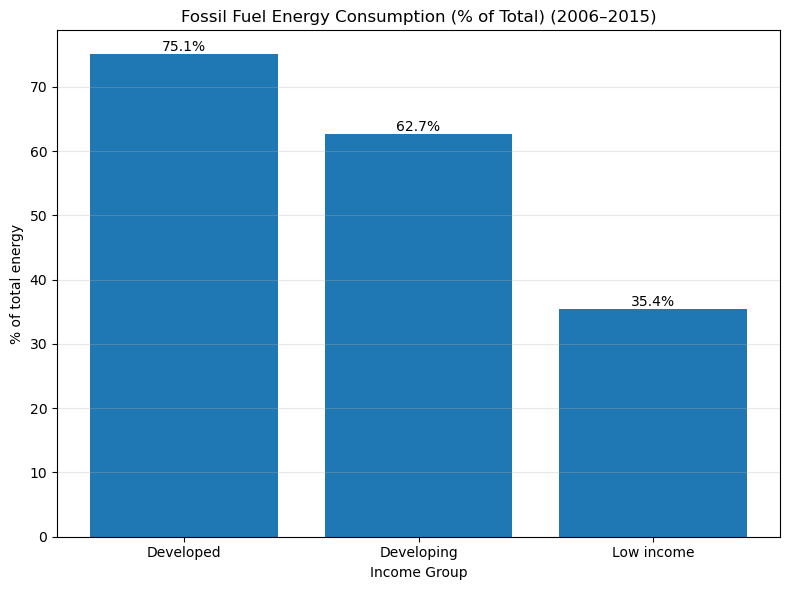

In [13]:
# --- column ---
fossil_col = 'average_value_Fossil fuel energy consumption (% of total)'

# --- clean ---
df2 = energy_merged[['Year', 'DevelopmentStatus', fossil_col]].copy()
df2['Year'] = pd.to_numeric(df2['Year'], errors='coerce')
df2[fossil_col] = pd.to_numeric(df2[fossil_col], errors='coerce')
df2 = df2.dropna(subset=['Year', 'DevelopmentStatus', fossil_col])
df2['Year'] = df2['Year'].astype(int)

# --- last 10 years ---
recent_years = sorted(df2['Year'].unique())[-10:]
recent_df2 = df2[df2['Year'].isin(recent_years)]

group_avg2 = (
    recent_df2.groupby('DevelopmentStatus')[fossil_col]
    .mean()
    .reindex(['Developed', 'Developing', 'Low income'])
)

groups2 = group_avg2.index.tolist()
values2 = group_avg2.values

# --- plot ---
plt.figure(figsize=(8, 6))
bars = plt.bar(groups2, values2)

plt.title(f'Fossil Fuel Energy Consumption (% of Total) ({recent_years[0]}–{recent_years[-1]})')
plt.xlabel('Income Group')
plt.ylabel('% of total energy')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    h = bar.get_height()
    if np.isfinite(h):
        plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [14]:
# Bar graph: Average Fossil Fuel vs Renewable Energy Consumption by IncomeGroup

# Metrics
fossil_col = 'average_value_Fossil fuel energy consumption (% of total)'
renewable_col = 'average_value_Renewable energy consumption (% of total final energy consumption)'

# Merge energy_df with meta_df to get IncomeGroup
energy_with_income = energy_df.merge(
    meta_df[['Country Code', 'IncomeGroup']],
    left_on='Country Code',
    right_on='Country Code',
    how='left'
)

# Group by IncomeGroup only, take mean of both metrics
income_energy = energy_with_income.groupby('IncomeGroup').agg({
    fossil_col: 'mean',
    renewable_col: 'mean'
}).reset_index()

# Filter to rows with data
income_energy = income_energy.dropna()

# Reshape data for grouped bar chart
income_energy_melted = income_energy.melt(
    id_vars='IncomeGroup',
    value_vars=[fossil_col, renewable_col],
    var_name='Energy Type',
    value_name='Percentage'
)

# Create grouped bar chart
fig = px.bar(
    income_energy_melted,
    x='IncomeGroup',
    y='Percentage',
    color='Energy Type',
    color_discrete_map={fossil_col: '#d62728', renewable_col: '#2ca02c'},
    title='Average Fossil Fuel vs Renewable Energy Consumption by Income Group',
    labels={'Percentage': 'Average Consumption (%)'},
    barmode='group'
)

fig.update_xaxes(title_text='Income Group')
fig.update_layout(
    template='plotly_white',
    width=1000,
    height=600,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5
    ),
    margin=dict(l=60, r=30, t=110, b=60)
)
fig.show()

print(f"Income Groups: {income_energy['IncomeGroup'].unique()}")

Income Groups: <ArrowStringArray>
['High income', 'Low income', 'Lower middle income', 'Upper middle income']
Length: 4, dtype: str


In [15]:
# Line plot: Fossil and Renewable Energy - Bottom 50% vs Top 50% Income Groups
# Fossil = solid line, Renewable = dashed line

# Metrics
fossil_col = 'average_value_Fossil fuel energy consumption (% of total)'
renewable_col = 'average_value_Renewable energy consumption (% of total final energy consumption)'

# Merge energy_df with meta_df to get IncomeGroup
energy_with_income = energy_df.merge(
    meta_df[['Country Code', 'IncomeGroup']],
    left_on='Country Code',
    right_on='Country Code',
    how='left'
)

# Create income tier grouping: Bottom 50% vs Top 50%
def categorize_income_tier(income_group):
    if income_group in ['Low income', 'Lower middle income']:
        return 'Bottom 50%'
    elif income_group in ['Upper middle income', 'High income']:
        return 'Top 50%'
    else:
        return income_group

energy_with_income['IncomeTier'] = energy_with_income['IncomeGroup'].apply(categorize_income_tier)

# Group by Year and IncomeTier, take mean of both metrics
year_tier_energy = energy_with_income.groupby(['Year', 'IncomeTier']).agg({
    fossil_col: 'mean',
    renewable_col: 'mean'
}).reset_index()

# Filter to rows with data
year_tier_energy = year_tier_energy.dropna()

# Create figure
fig = go.Figure()

# Define colors for each tier
colors = {
    'Bottom 50%': '#d62728',
    'Top 50%': '#1f77b4'
}

# Add lines for each tier
for tier in ['Bottom 50%', 'Top 50%']:
    data = year_tier_energy[year_tier_energy['IncomeTier'] == tier]

    # Fossil fuel - solid line
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data[fossil_col],
        name=f'{tier} (Fossil)',
        mode='lines',
        line=dict(color=colors.get(tier, '#000000'), width=3, dash='solid'),
        legendgroup=tier,
        hovertemplate='%{fullData.name}<br>Year: %{x}<br>Consumption: %{y:.2f}%<extra></extra>'
    ))

    # Renewable - dashed line
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data[renewable_col],
        name=f'{tier} (Renewable)',
        mode='lines',
        line=dict(color=colors.get(tier, '#000000'), width=3, dash='dash'),
        legendgroup=tier,
        hovertemplate='%{fullData.name}<br>Year: %{x}<br>Consumption: %{y:.2f}%<extra></extra>'
    ))

fig.update_layout(
    title='Fossil (solid) vs Renewable (dashed) Energy: Bottom 50% vs Top 50% Income Groups',
    xaxis_title='Year',
    yaxis_title='Energy Consumption (%)',
    template='plotly_white',
    hovermode='x unified',
    height=600
)

fig.show()

print(f"Years covered: {year_tier_energy['Year'].min()} to {year_tier_energy['Year'].max()}")

Years covered: 1990 to 2015
